In [1]:
import pandas as pd
from  trading_agent_class import Trading_Agent
from memory_class import memory

In [2]:
vix_options = pd.read_csv("data/vix_options.csv",parse_dates=["as_of_date", "expiration_date"],)
vix_data = pd.read_csv("data/vix_data.csv", parse_dates=["Date"])
vvix_data = pd.read_csv("data/vvix_data.csv", parse_dates=["Date"])
spx_data = pd.read_csv("data/spx_data.csv", parse_dates=["Date"])

feed_start = "2024-01-01"
start_date = "2024-06-01"
end_date = "2026-05-01"

date_list = vix_data["Date"].unique()

In [3]:
Agents = [
    Trading_Agent(name="rv22", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 1, VRP_lt_threshold = 999, VRP_garch_threshold = 999),
    Trading_Agent(name="lt", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 999, VRP_lt_threshold = 1, VRP_garch_threshold = 999),
    Trading_Agent(name="garch", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 999, VRP_lt_threshold = 999, VRP_garch_threshold = 0.01),
]

for today in date_list:
    vix = vix_data[vix_data["Date"] == today]["Close"].item()
    vvix = vvix_data[vvix_data["Date"] == today]["Close"].item()
    spx = spx_data[spx_data["Date"] == today]["Close"].item()
    rv22 = spx_data[spx_data["Date"] == today]["RV22"].item()
    option_chain = vix_options[vix_options["as_of_date"] == today]

    for agent in Agents:
        agent.feed_data(vix,vvix,spx,rv22)
        if not option_chain.empty:
            trading_signal = agent.signal()
            agent.trade(option_chain, trading_signal)
            agent.calculate_pnl(option_chain, today, vix)


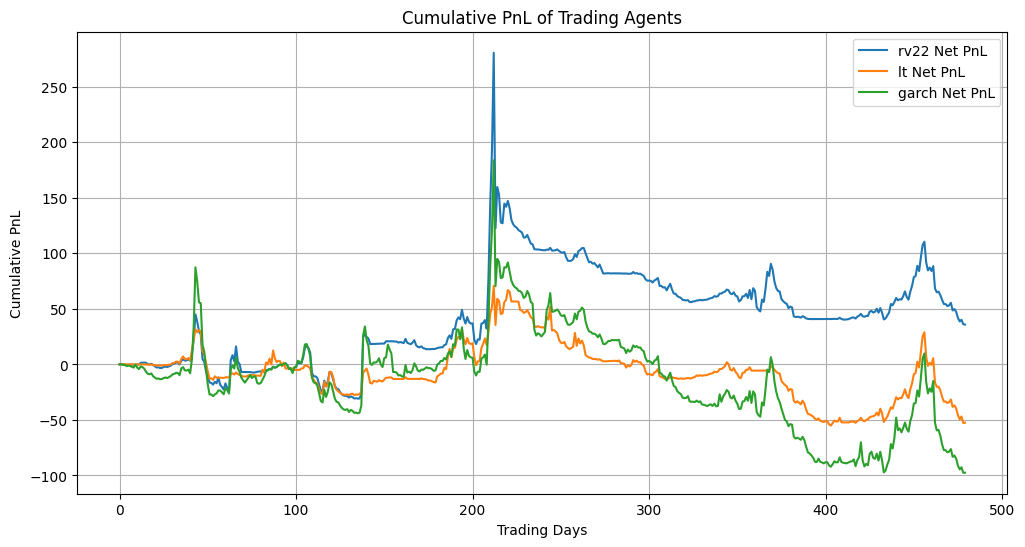

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for agent in Agents:
    cum_pnl = agent.get_cum_pnl()
    plt.plot(cum_pnl, label=f"{agent.name} Net PnL")

plt.title("Cumulative PnL of Trading Agents")
plt.xlabel("Trading Days")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)
plt.show()


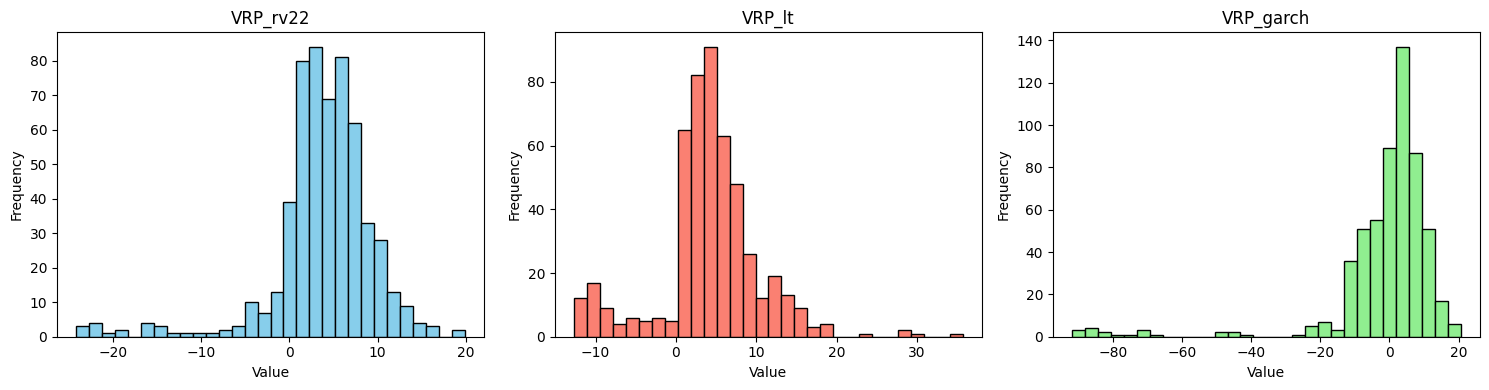

In [ ]:
a = Agents[0]

test_len = 30

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

# Plot histogram for VRP_rv22
plt.subplot(1, 3, 1)
plt.hist(a.memory.VRP_rv22, bins=30, color='skyblue', edgecolor='black')
plt.title('VRP_rv22')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot histogram for VRP_lt
plt.subplot(1, 3, 2)
plt.hist(a.memory.VRP_lt, bins=30, color='salmon', edgecolor='black')
plt.title('VRP_lt')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot histogram for VRP_garch
plt.subplot(1, 3, 3)
plt.hist(a.memory.VRP_garch, bins=30, color='lightgreen', edgecolor='black')
plt.title('VRP_garch')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
a = Agents[0]
import matplotlib.pyplot as plt
import numpy as np


def random_window(arr, test_len):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return arr
    if arr.size <= test_len:
        return arr
    start = np.random.randint(0, arr.size - test_len + 1)
    return arr[start : start + test_len]


test_len = a.test_length
rv22_sample = random_window(a.memory.VRP_rv22, test_len)
lt_sample = random_window(a.memory.VRP_lt, test_len)
garch_sample = random_window(a.memory.VRP_garch, test_len)

plt.figure(figsize=(15, 4))

# Plot histogram for VRP_rv22
plt.subplot(1, 3, 1)
plt.hist(rv22_sample, bins=30, color='skyblue', edgecolor='black')
plt.title(f'VRP_rv22 (random window={test_len})')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot histogram for VRP_lt
plt.subplot(1, 3, 2)
plt.hist(lt_sample, bins=30, color='salmon', edgecolor='black')
plt.title(f'VRP_lt (random window={test_len})')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Plot histogram for VRP_garch
plt.subplot(1, 3, 3)
plt.hist(garch_sample, bins=30, color='lightgreen', edgecolor='black')
plt.title(f'VRP_garch (random window={test_len})')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()